In [37]:
# Import the necessary libraries and read the data.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("/Users/serhatguldogan/Library/CloudStorage/OneDrive-KocUniversitesi/Project_/RAW DATA/BTC_1sec.csv")


In [38]:
df.head()

,Unnamed: 0,system_time,midpoint,spread,buys,sells,bids_distance_0,bids_distance_1,bids_distance_2,bids_distance_3,...,asks_market_notional_5,asks_market_notional_6,asks_market_notional_7,asks_market_notional_8,asks_market_notional_9,asks_market_notional_10,asks_market_notional_11,asks_market_notional_12,asks_market_notional_13,asks_market_notional_14
0,0,2021-04-07 11:32:42.122161+00:00,56035.995,0.01,0.0,0.0,-8.922836e-08,-2.676851e-07,-0.00005,-0.000245,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,2021-04-07 11:32:43.122161+00:00,56035.995,0.01,0.0,0.0,-8.922836e-08,-2.676851e-07,-0.00005,-0.000245,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,2021-04-07 11:32:44.122161+00:00,56035.995,0.01,0.0,0.0,-8.922836e-08,-2.676851e-07,-0.00005,-0.000245,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3,2021-04-07 11:32:45.122161+00:00,56035.995,0.01,0.0,0.0,-8.922836e-08,-2.676851e-07,-0.00005,-0.000245,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4,2021-04-07 11:32:46.122161+00:00,56035.995,0.01,0.0,0.0,-8.922836e-08,-2.676851e-07,-0.00005,-0.000245,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [39]:
#  Create a column that is 1 if the price changed and 0 if not.
# .diff() calculates the difference with the previous row.
df['price_changed'] = (df['midpoint'].diff() != 0).astype(int)

# Use the .rolling() method to sum the changes over a 60-second window.
df['changes_in_last_minute'] = df['price_changed'].rolling(window=60).sum()

In [40]:
# Observe the new dataframe.
df.head()



,Unnamed: 0,system_time,midpoint,spread,buys,sells,bids_distance_0,bids_distance_1,bids_distance_2,bids_distance_3,...,asks_market_notional_7,asks_market_notional_8,asks_market_notional_9,asks_market_notional_10,asks_market_notional_11,asks_market_notional_12,asks_market_notional_13,asks_market_notional_14,price_changed,changes_in_last_minute
0,0,2021-04-07 11:32:42.122161+00:00,56035.995,0.01,0.0,0.0,-8.922836e-08,-2.676851e-07,-0.00005,-0.000245,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,NaN
1,1,2021-04-07 11:32:43.122161+00:00,56035.995,0.01,0.0,0.0,-8.922836e-08,-2.676851e-07,-0.00005,-0.000245,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN
2,2,2021-04-07 11:32:44.122161+00:00,56035.995,0.01,0.0,0.0,-8.922836e-08,-2.676851e-07,-0.00005,-0.000245,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN
3,3,2021-04-07 11:32:45.122161+00:00,56035.995,0.01,0.0,0.0,-8.922836e-08,-2.676851e-07,-0.00005,-0.000245,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN
4,4,2021-04-07 11:32:46.122161+00:00,56035.995,0.01,0.0,0.0,-8.922836e-08,-2.676851e-07,-0.00005,-0.000245,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN


In [41]:
# Fill the NaN values in that specific column with 0
df['changes_in_last_minute'].fillna(0, inplace=True)

In [42]:
# Again observe the dataframe now.
df.head()

,Unnamed: 0,system_time,midpoint,spread,buys,sells,bids_distance_0,bids_distance_1,bids_distance_2,bids_distance_3,...,asks_market_notional_7,asks_market_notional_8,asks_market_notional_9,asks_market_notional_10,asks_market_notional_11,asks_market_notional_12,asks_market_notional_13,asks_market_notional_14,price_changed,changes_in_last_minute
0,0,2021-04-07 11:32:42.122161+00:00,56035.995,0.01,0.0,0.0,-8.922836e-08,-2.676851e-07,-0.00005,-0.000245,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0.0
1,1,2021-04-07 11:32:43.122161+00:00,56035.995,0.01,0.0,0.0,-8.922836e-08,-2.676851e-07,-0.00005,-0.000245,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0
2,2,2021-04-07 11:32:44.122161+00:00,56035.995,0.01,0.0,0.0,-8.922836e-08,-2.676851e-07,-0.00005,-0.000245,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0
3,3,2021-04-07 11:32:45.122161+00:00,56035.995,0.01,0.0,0.0,-8.922836e-08,-2.676851e-07,-0.00005,-0.000245,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0
4,4,2021-04-07 11:32:46.122161+00:00,56035.995,0.01,0.0,0.0,-8.922836e-08,-2.676851e-07,-0.00005,-0.000245,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0


In [43]:
# Calculate the difference between each row in the count series
df['increments'] = df['changes_in_last_minute'].diff()

# The first row will be NaN after .diff(), so we can fill it with 0
df['increments'].fillna(0, inplace=True)

In [44]:
# Again observe the dataframe.
df.head()

,Unnamed: 0,system_time,midpoint,spread,buys,sells,bids_distance_0,bids_distance_1,bids_distance_2,bids_distance_3,...,asks_market_notional_8,asks_market_notional_9,asks_market_notional_10,asks_market_notional_11,asks_market_notional_12,asks_market_notional_13,asks_market_notional_14,price_changed,changes_in_last_minute,increments
0,0,2021-04-07 11:32:42.122161+00:00,56035.995,0.01,0.0,0.0,-8.922836e-08,-2.676851e-07,-0.00005,-0.000245,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0.0,0.0
1,1,2021-04-07 11:32:43.122161+00:00,56035.995,0.01,0.0,0.0,-8.922836e-08,-2.676851e-07,-0.00005,-0.000245,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0
2,2,2021-04-07 11:32:44.122161+00:00,56035.995,0.01,0.0,0.0,-8.922836e-08,-2.676851e-07,-0.00005,-0.000245,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0
3,3,2021-04-07 11:32:45.122161+00:00,56035.995,0.01,0.0,0.0,-8.922836e-08,-2.676851e-07,-0.00005,-0.000245,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0
4,4,2021-04-07 11:32:46.122161+00:00,56035.995,0.01,0.0,0.0,-8.922836e-08,-2.676851e-07,-0.00005,-0.000245,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0


In [45]:
# Load the last minute changes' count into an array.
arr = np.array(df["changes_in_last_minute"])

In [46]:
# We do the autocorrelation analysis on the array [N(1)-N(0),N(2)-N(1),N(3)-N(2),....],
# where N(t) means the price changes up to MINUTE t.
arr_0 = []
for i in range(59,len(arr),60):
    arr_0.append(arr[i])

arr_0 = np.array(arr_0)



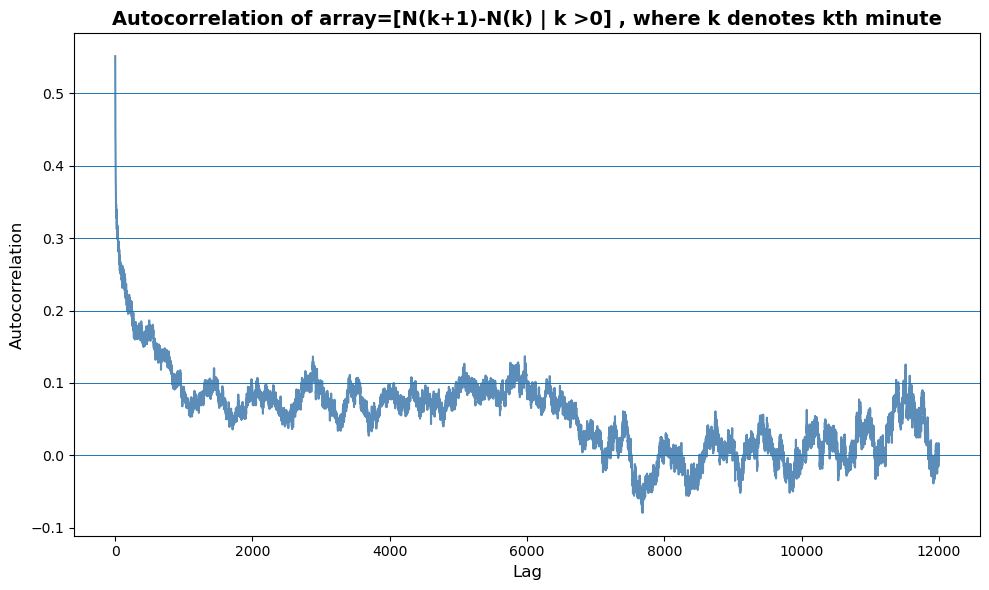

In [47]:
# Plot the autocorrelations up to a certain lag. One may decide to cut the plot at the time that the autocorrelations hit the x-axis, since the rest of the plot is noise.
autocorrs = [np.corrcoef(arr_0[:-lag], arr_0[lag:])[0,1] if lag != 0 else 1 for lag in range(1,12001)]

plt.figure(figsize=(10, 6))
plt.plot(range(1,12001), autocorrs, color='#5C8DB8')
plt.xlabel('Lag', fontsize=12)
plt.ylabel('Autocorrelation', fontsize=12)
plt.title('Autocorrelation of array=[N(k+1)-N(k) | k >0] , where k denotes kth minute', fontsize=14, fontweight='bold')
plt.tight_layout()
for y in [0.5,0.4,0.3, 0.2, 0.1, 0.0]:
    plt.axhline(y=y, linewidth=0.7, linestyle='-')
plt.show()
